# 종합 분석

## 0. 프로젝트 목표 재확인 및 이 노트북의 범위

프로젝트 기획서(직업훈련 수강생 조기 이탈 예측 및 데이터 기반 개입 전략 수립)의 핵심 제약은
다음과 같습니다.

> **수강 4주차(등록 후 28일) 시점까지 누적된 데이터만으로 최종 이탈 여부를 사전 예측한다.**

01~05번 노트북은 각 파일을 깊이 있게 검증하기 위해 **수강 전체 기간**의 데이터를 사용했습니다.
그런데 실제로 SQL 피처마트(`student_mart_w4`)와 머신러닝 모델에 들어갈 피처는 **28일 이내
데이터로만** 만들어야 하므로, 전체 기간 기준으로 확인한 패턴이 28일 시점에도 그대로 보이는지
다시 확인할 필요가 있습니다.

이 노트북은 기획서 STEP 1(이탈 패턴 EDA)에 명시된 4개 항목 + STEP 2 피처마트 설계를 미리
검증하는 5번째 섹션으로 구성합니다. **모델링(STEP 2의 학습)·SQL 이식·Tableau 대시보드·국내
공공데이터 분석은 이 노트북의 범위 밖**이며, 순수 EDA 결과만 다룹니다.

1. 주차별 클릭 수 추이 시각화 — 이탈 전 행동 변화 및 임계 시점 포착
2. 과제 미제출 누적 패턴 분석 (28일 이내 마감 과제 기준)
3. 인구통계(연령대·교육수준·장애 여부) x 이탈률 교차 분석
4. 과정 유형(과목)별 이탈 분포 비교
5. **"4주차 피처마트" EDA 사전 검증** — 기획서 STEP 2의 SQL 스니펫(`cumulative_clicks`,
   `forum_click_ratio`, `avg_assignment_delay`, `unsubmitted_count`)을 파이썬으로 먼저
   재현해, 실제로 완수/이탈을 가르는 신호가 있는지 SQL·모델링 착수 전에 확인합니다.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False

info = pd.read_csv("../CSV_files/studentInfo.csv")
reg = pd.read_csv("../CSV_files/studentRegistration.csv")
courses = pd.read_csv("../CSV_files/courses.csv")
vle = pd.read_csv("../CSV_files/vle.csv")
st_vle = pd.read_csv("../CSV_files/studentVle.csv")
assess = pd.read_csv("../CSV_files/assessments.csv")
st_assess = pd.read_csv("../CSV_files/studentAssessment.csv")

info["label_churn"] = info["final_result"].apply(lambda x: "이탈" if x == "Withdrawn" else "완수")
roster = info[["id_student", "code_module", "code_presentation", "label_churn"]].drop_duplicates()

print("학생-과목 등록 기록 수:", len(roster))
print(info["label_churn"].value_counts(normalize=True).round(3))

학생-과목 등록 기록 수: 32593
label_churn
완수    0.688
이탈    0.312
Name: proportion, dtype: float64


# 1. 주차별 클릭 수 추이 — 이탈 전 행동 변화 및 임계 시점 포착

전체 기간(04번)이 아니라 **등록 후 0~3주차(0~27일, 4주차 예측 시점 직전까지)만** 잘라서
평균 클릭수 추이를 봅니다. 여기서는 04번과 달리 "아직 재학 중인 이탈 학생만" 걸러내는 마스킹을
하지 않습니다 — 4주차 피처마트는 이미 이탈한 학생의 클릭수도 그대로(0에 가깝게) 포함시켜서
계산해야 하는, **고정된 달력 관측창**이기 때문입니다.

[0~3주차 평균 클릭수 - 전원 포함, 고정 관측창]
label_churn    완수    이탈
week                   
0            74.0  34.7
1            66.5  30.0
2            84.3  40.9
3            69.1  27.3


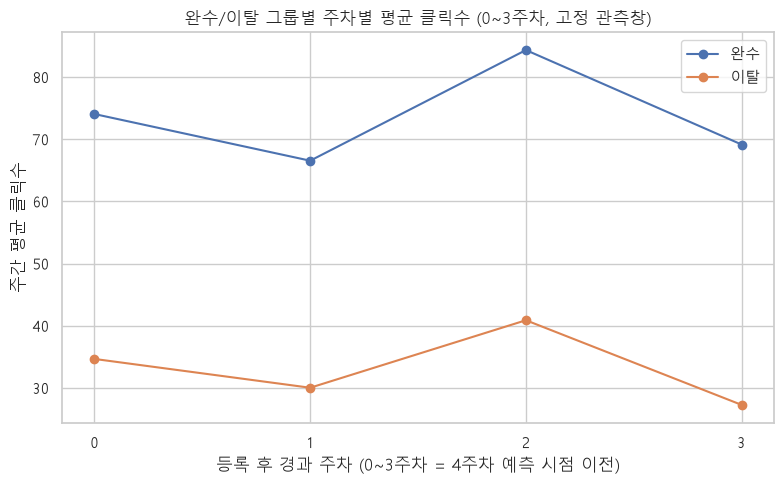


전체 이탈자 10072명 중 28일 이내 이미 이탈: 5055명 (50.2%)


In [8]:
sv28 = st_vle[st_vle["date"] <= 28].copy()
sv28["week"] = (sv28["date"] // 7).astype(int).clip(upper=3)

weekly = sv28.groupby(["id_student", "code_module", "code_presentation", "week"])["sum_click"].sum().reset_index()

weeks_df = pd.DataFrame({"week": range(0, 4), "_k": 1})
roster["_k"] = 1
grid = roster.merge(weeks_df, on="_k").drop(columns="_k")
grid = grid.merge(weekly, on=["id_student", "code_module", "code_presentation", "week"], how="left")
grid["sum_click"] = grid["sum_click"].fillna(0)
roster.drop(columns="_k", inplace=True)

ts = grid.groupby(["week", "label_churn"])["sum_click"].mean().unstack()
print("[0~3주차 평균 클릭수 - 전원 포함, 고정 관측창]")
print(ts.round(1))

plt.figure(figsize=(8, 5))
plt.plot(ts.index, ts["완수"], marker="o", label="완수")
plt.plot(ts.index, ts["이탈"], marker="o", label="이탈")
plt.xlabel("등록 후 경과 주차 (0~3주차 = 4주차 예측 시점 이전)")
plt.ylabel("주간 평균 클릭수")
plt.title("완수/이탈 그룹별 주차별 평균 클릭수 (0~3주차, 고정 관측창)")
plt.xticks(range(0, 4))
plt.legend()
plt.tight_layout()
plt.show()

# 4주차(28일) 시점에 이미 이탈(취소)한 학생 비율
wd = reg.dropna(subset=["date_unregistration"])
already_left = (wd["date_unregistration"] <= 28).sum()
print(f"\n전체 이탈자 {len(wd)}명 중 28일 이내 이미 이탈: {already_left}명 ({already_left/len(wd)*100:.1f}%)")

**[확인 결과]** 0주차부터 이미 완수(74.0회) vs 이탈(34.7회)로 약 2.1배 격차가 나타나고, 이
격차는 3주차까지 계속 유지됩니다(69.1 vs 27.3). 즉 **"이탈 전 서서히 활동이 준다"는 절벽형
패턴이 아니라, 등록 직후부터 이미 낮은 참여도를 보이는 누적형 패턴**이 28일이라는 짧은
관측창 안에서도 뚜렷하게 나타납니다 — 04번에서 전체 기간으로 봤던 결론과 일치합니다.

**[모델링 팀에 특히 중요한 경고]** 최종적으로 이탈(Withdrawn) 처리되는 학생 중 **50.2%가
28일 시점에 이미 이탈(취소) 처리되어 있습니다.** 즉 4주차 피처마트의 절반가량은 "앞으로
이탈할지"를 예측하는 게 아니라 "이미 이탈한 사실"을 사후적으로 확인하는 것에 가깝습니다.
이는 라벨 누수(label leakage)는 아니지만(피처 자체는 28일 이내 값만 사용하므로), 모델
성능(특히 Recall)이 높게 나오더라도 상당 부분이 "이미 벌어진 이탈"을 감지한 결과일 수 있다는
점을 감안하고 해석해야 합니다.

# 2. 과제 미제출 누적 패턴 분석 (28일 이내 마감 과제 기준)

기획서의 SQL 스니펫은 `WHERE a.date <= 28`로 마감일이 28일 이내인 과제만 걸러 지연일수와
미제출 건수를 집계합니다. 이를 그대로 파이썬으로 재현합니다.

In [9]:
assess28 = assess[(assess["date"] <= 28) & (assess["weight"] > 0)]
st_valid = st_assess[st_assess["is_banked"] == 0].copy()

# 28일 이내 마감되는 weight>0 과제가 하나도 없는 과목-학기 확인
have_assess = assess28.groupby(["code_module", "code_presentation"]).size()
all_courses_idx = courses.set_index(["code_module", "code_presentation"]).index
missing_courses = [c for c in all_courses_idx if c not in have_assess.index]
print("28일 이내 weight>0 과제가 하나도 없는 과목-학기:", missing_courses)
print(f"({len(missing_courses)} / {len(all_courses_idx)}개 과목-학기)")

# 학생별 28일 이내 마감 과제의 지연일수·미제출 건수
exp = roster.merge(assess28[["code_module", "code_presentation", "id_assessment", "date"]],
                    on=["code_module", "code_presentation"], how="inner")
exp = exp.merge(st_valid[["id_student", "id_assessment", "date_submitted"]],
                 on=["id_student", "id_assessment"], how="left")
exp["is_submitted"] = exp["date_submitted"].notna()
exp["delay"] = exp["date_submitted"] - exp["date"]

per_student = exp.groupby(["id_student", "code_module", "code_presentation", "label_churn"]).agg(
    n_due=("id_assessment", "count"),
    n_submitted=("is_submitted", "sum"),
    avg_delay=("delay", lambda x: x[x.notna()].mean())
).reset_index()
per_student["unsubmitted_count"] = per_student["n_due"] - per_student["n_submitted"]

print(f"\n28일 이내 마감 과제가 있는 과목에 속한 학생-과목 조합: {len(per_student)} / 전체 {len(roster)}"
      f" ({len(per_student)/len(roster)*100:.1f}%)")
print("\n[28일 이내 마감 과제 기준 - 완수/이탈 그룹별]")
print(per_student.groupby("label_churn")[["unsubmitted_count", "avg_delay"]].agg(["mean", "median"]).round(2))

28일 이내 weight>0 과제가 하나도 없는 과목-학기: [('BBB', '2014J'), ('EEE', '2013J'), ('EEE', '2014J'), ('EEE', '2014B'), ('GGG', '2013J'), ('GGG', '2014J'), ('GGG', '2014B')]
(7 / 22개 과목-학기)

28일 이내 마감 과제가 있는 과목에 속한 학생-과목 조합: 24833 / 전체 32593 (76.2%)

[28일 이내 마감 과제 기준 - 완수/이탈 그룹별]
            unsubmitted_count        avg_delay       
                         mean median      mean median
label_churn                                          
완수                       0.09    0.0     -0.75   -1.0
이탈                       0.58    1.0      0.85    0.0


**[확인 결과]** 28일 이내 마감 과제가 있는 학생-과목 조합만 놓고 보면, 미제출 건수는 완수
평균 0.09건(중앙값 0)인데 이탈은 평균 0.58건(중앙값 1건)이고, 평균 지연일수도 완수는
-0.75일(미리 제출)인데 이탈은 +0.85일(지연 제출)로 방향 자체가 반대입니다. 짧은 관측창
안에서도 뚜렷한 신호입니다.

**[SQL 피처마트 설계 시 반드시 반영해야 할 데이터 공백]** 22개 과목-학기 중 **7개(EEE
전체 3개 학기, GGG 전체 3개 학기, BBB_2014J)는 28일 이내 마감되는 채점 대상(weight>0)
과제가 단 하나도 없습니다.** 이 과목들의 학생(전체의 약 23.8%)은 `unsubmitted_count`가
실제로 "잘 제출해서 0건"이 아니라 "애초에 낼 과제 자체가 없어서 0건"인데, 기획서 SQL의
`COALESCE(..., 0)` 처리로는 이 둘이 똑같이 0으로 뭉개집니다. 이 상태로 모델을 학습시키면
"미제출 0건 = 안전"이라는 잘못된 신호가 EEE·GGG 수강생 전체에 걸릴 수 있으므로, **과제
관련 피처와 함께 "28일 이내 과제 존재 여부" 플래그를 별도 피처로 추가하는 것을 제안**합니다.

# 3. 인구통계(연령대·교육수준·장애 여부) x 이탈률 교차 분석

성별·연령대·교육수준·장애 여부는 시간에 따라 변하지 않는 속성이므로, 01번에서 전체 기간
기준으로 계산한 결과를 그대로 사용해도 28일 시점 분석에 문제가 없습니다.

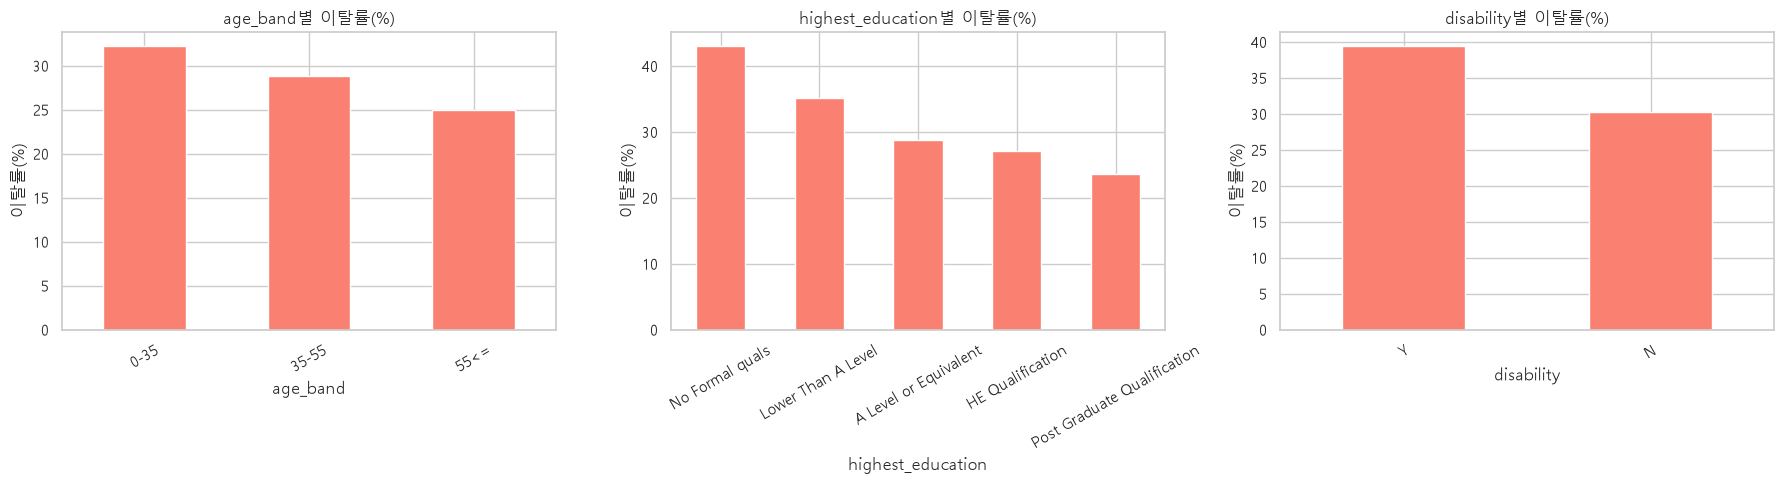

[age_band별 이탈률(%)]
age_band
0-35     32.2
35-55    28.8
55<=     25.0
Name: label_churn, dtype: float64

[highest_education별 이탈률(%)]
highest_education
No Formal quals                42.9
Lower Than A Level             35.1
A Level or Equivalent          28.7
HE Qualification               27.1
Post Graduate Qualification    23.6
Name: label_churn, dtype: float64

[disability별 이탈률(%)]
disability
Y    39.3
N    30.3
Name: label_churn, dtype: float64



In [10]:
demo_cols = ["age_band", "highest_education", "disability"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, demo_cols):
    rate = info.groupby(col)["label_churn"].value_counts(normalize=True).unstack().fillna(0) * 100
    rate = rate.sort_values("이탈", ascending=False)
    rate["이탈"].plot(kind="bar", color="salmon", ax=ax)
    ax.set_title(f"{col}별 이탈률(%)")
    ax.set_ylabel("이탈률(%)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

for col in demo_cols:
    rate = (info.groupby(col)["label_churn"].apply(lambda x: (x == "이탈").mean() * 100)).round(1)
    print(f"[{col}별 이탈률(%)]")
    print(rate.sort_values(ascending=False))
    print()

**[확인 결과]** 연령대는 0-35세(32.2%)가 35-55세(28.8%)·55세 이상(25.0%)보다 이탈률이 다소
높고, 교육수준은 No Formal quals(42.9%)가 가장 높고 Post Graduate Qualification(23.6%)이
가장 낮아 순서대로 뚜렷하게 갈립니다. 장애 여부는 있음(Y, 39.3%)이 없음(N, 30.3%)보다
높습니다. 다만 01번의 Cramér's V 분석 결과 이 개별 변수들의 연관성 강도는
0.03~0.08 수준으로 code_module(0.177)보다 약합니다. 4주차 피처마트에는 이 인구통계
변수들을 그대로 피처로 포함하되(시간 불변이므로 28일 제약과 무관), 단일 변수보다는 행동
지표(클릭수, 과제)와 결합했을 때 예측력이 커질 것으로 예상합니다.

# 4. 과정 유형(과목)별 이탈 분포 비교

과목 코드(code_module)도 시간 불변 속성입니다. 05번에서 확인한 과목별 이탈률 차이를
재인용하고, 4주차 피처마트에도 과목 코드를 반드시 피처로 포함해야 하는 근거를 확인합니다.

[과목(code_module)별 이탈률(%)]
code_module
CCC    44.5
DDD    35.9
FFF    31.0
BBB    30.2
EEE    24.6
AAA    16.8
GGG    11.5
Name: label_churn, dtype: float64


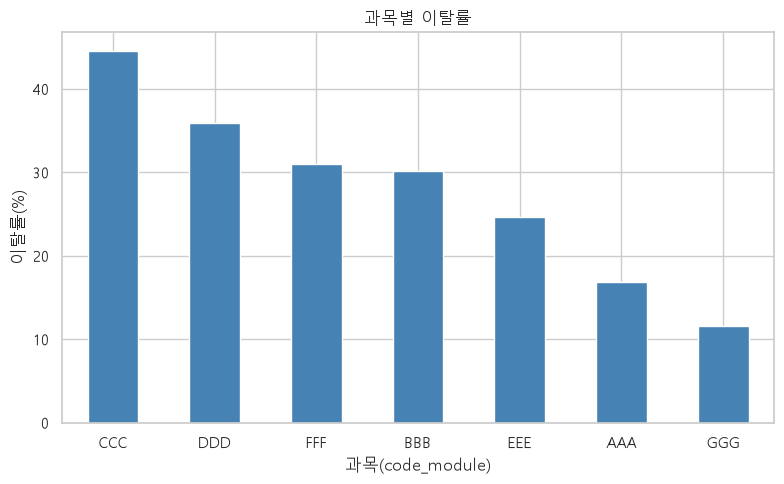

In [11]:
rate_by_module = info.groupby("code_module")["label_churn"].apply(lambda x: (x == "이탈").mean() * 100).sort_values(ascending=False)
print("[과목(code_module)별 이탈률(%)]")
print(rate_by_module.round(1))

plt.figure(figsize=(8, 5))
rate_by_module.plot(kind="bar", color="steelblue")
plt.ylabel("이탈률(%)")
plt.xlabel("과목(code_module)")
plt.title("과목별 이탈률")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**[확인 결과 - 05번 재인용]** CCC(44.5%)가 가장 높고 GGG(11.5%)가 가장 낮아 최대 3.9배
차이가 납니다. 05번에서 이 차이가 학기 길이·개강 시즌과는 거의 무관하고(상관계수 -0.17,
계절 차 1%p 이내), 일부는 과목별 학생 구성(연령·이전 수강 이력)으로 설명되지만 전부는
아니라는 것도 확인했습니다. **4주차 피처마트에 code_module을 범주형 피처로 반드시
포함**해야 하고, 2번 섹션에서 확인한 "28일 이내 과제 유무"도 과목마다 다르므로(EEE·GGG는
과제 신호 자체가 없음) 과목별로 사용 가능한 신호의 종류 자체가 다르다는 점을 유의해야
합니다.

# 5. "4주차 피처마트" EDA 사전 검증

기획서 STEP 2의 SQL 스니펫이 만들려는 4개 핵심 피처(`cumulative_clicks`,
`forum_click_ratio`, `avg_assignment_delay`, `unsubmitted_count`)를 파이썬으로 동일한 로직
(`date <= 28`)으로 재현해서, SQL·모델링에 들어가기 전에 실제로 완수/이탈을 가르는 신호가
있는지 미리 검증합니다.

[4주차 피처마트(EDA 재현) - 완수/이탈 그룹별 요약]
            cumulative_clicks        forum_click_ratio         \
                         mean median              mean median   
label_churn                                                     
완수                    372.692  235.0             0.212  0.170   
이탈                    170.505   59.0             0.117  0.008   

            avg_assignment_delay        unsubmitted_count         
                            mean median              mean median  
label_churn                                                       
완수                        -0.500    0.0             0.067    0.0  
이탈                         0.317    0.0             0.479    0.0  

28일 시점까지 클릭 0(=완전 무활동)인 비율:
label_churn
완수     3.2
이탈    30.4
Name: cumulative_clicks, dtype: float64


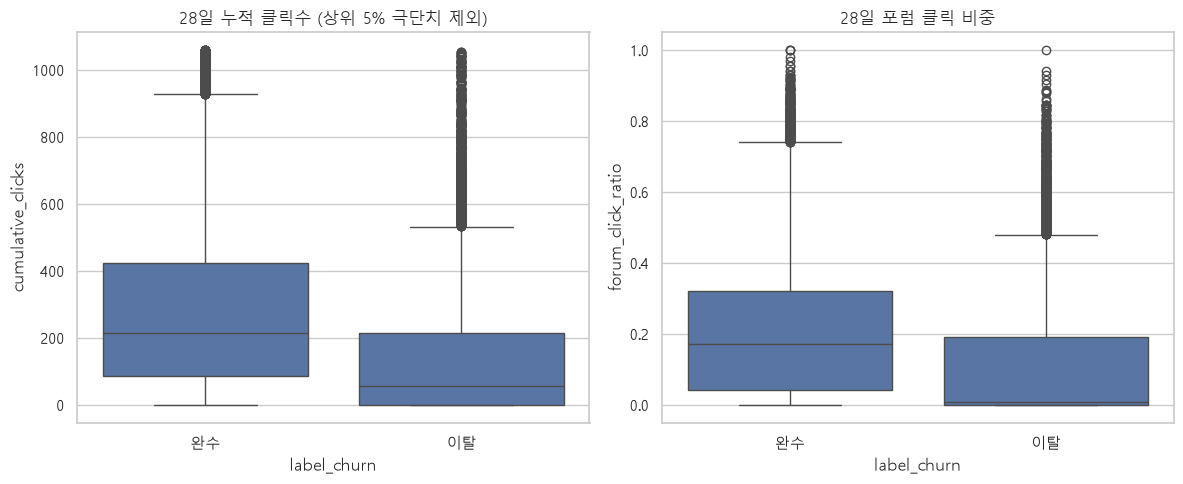

In [12]:
# cumulative_clicks (28일 이내 누적 클릭수)
cum_clicks = sv28.groupby(["id_student", "code_module", "code_presentation"])["sum_click"].sum().reset_index(name="cumulative_clicks")
mart = roster.merge(cum_clicks, on=["id_student", "code_module", "code_presentation"], how="left")
mart["cumulative_clicks"] = mart["cumulative_clicks"].fillna(0)

# forum_click_ratio (28일 이내 포럼 클릭 비중)
sv28_type = sv28.merge(vle[["id_site", "activity_type"]], on="id_site", how="left")
forum_click = sv28_type[sv28_type["activity_type"] == "forumng"].groupby(
    ["id_student", "code_module", "code_presentation"])["sum_click"].sum().reset_index(name="forum_click")
mart = mart.merge(forum_click, on=["id_student", "code_module", "code_presentation"], how="left")
mart["forum_click"] = mart["forum_click"].fillna(0)
mart["forum_click_ratio"] = np.where(mart["cumulative_clicks"] > 0, mart["forum_click"] / mart["cumulative_clicks"], 0)

# avg_assignment_delay, unsubmitted_count (28일 이내 마감 과제 기준, 2번에서 계산한 per_student 재사용)
mart = mart.merge(
    per_student[["id_student", "code_module", "code_presentation", "avg_delay", "unsubmitted_count"]],
    on=["id_student", "code_module", "code_presentation"], how="left"
)
mart["avg_assignment_delay"] = mart["avg_delay"].fillna(0)
mart["unsubmitted_count"] = mart["unsubmitted_count"].fillna(0)

print("[4주차 피처마트(EDA 재현) - 완수/이탈 그룹별 요약]")
summary = mart.groupby("label_churn")[["cumulative_clicks", "forum_click_ratio", "avg_assignment_delay", "unsubmitted_count"]].agg(["mean", "median"]).round(3)
print(summary)

zero_click = mart.groupby("label_churn")["cumulative_clicks"].apply(lambda x: (x == 0).mean() * 100).round(1)
print("\n28일 시점까지 클릭 0(=완전 무활동)인 비율:")
print(zero_click)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=mart[mart["cumulative_clicks"] < mart["cumulative_clicks"].quantile(0.95)],
            x="label_churn", y="cumulative_clicks", ax=axes[0])
axes[0].set_title("28일 누적 클릭수 (상위 5% 극단치 제외)")
sns.boxplot(data=mart, x="label_churn", y="forum_click_ratio", ax=axes[1])
axes[1].set_title("28일 포럼 클릭 비중")
plt.tight_layout()
plt.show()

**[확인 결과 — EDA 최종 결론]** 4주차 피처마트에 들어갈 4개 피처 모두 28일이라는 짧은
관측창 안에서도 완수/이탈 간 뚜렷한 차이를 보입니다.

| 피처 | 완수 | 이탈 | 비고 |
|---|---|---|---|
| 28일 누적 클릭수 (평균/중앙값) | 372.7 / 235.0 | 170.5 / 59.0 | 완수가 약 2.2배(평균)~4배(중앙값) 많음 |
| 28일 시점 완전 무활동 비율 | 3.2% | 30.4% | 전체 기간 기준(1.7%/31.3%, 04번)과 거의 동일한 격차 — **이 신호는 이미 4주차에 다 드러남** |
| 28일 포럼 클릭 비중 (평균/중앙값) | 0.212 / 0.170 | 0.117 / 0.008 | 중앙값 격차가 특히 큼(0.170 vs 0.008) |
| 28일 이내 과제 미제출 건수 (평균, 전체 학생 기준) | 0.067 | 0.479 | 과제가 없는 과목(7/22)은 0으로 채움 |
| 28일 이내 과제 평균 지연일 (평균, 전체 학생 기준) | -0.50일(조기) | +0.32일(지연) | 방향 자체가 반대 |
| (참고) 28일 이내 과제가 있는 과목만 한정 시 미제출 건수/지연일 | 0.09건 / -0.75일 | 0.58건 / +0.85일 | 2번 섹션 `per_student` 기준 |

**[가장 중요한 결론]** 04번에서 "완수 1.7% vs 이탈 31.3%"였던 **VLE 무활동 비율이 28일
시점에서 이미 3.2% vs 30.4%로 사실상 동일한 크기로 나타납니다.** 즉 이 프로젝트의 핵심
전제("4주차 데이터만으로 이탈을 예측할 수 있다")는 데이터로 뒷받침됩니다 — 완수/이탈을
가르는 가장 강력한 신호(무활동 여부)는 학기 전체를 기다리지 않아도 첫 4주 안에 이미
드러납니다.

**[SQL/ML 단계로 넘기는 인수인계 노트]**
1. `cumulative_clicks`, `forum_click_ratio`는 강한 신호이므로 그대로 채택.
2. `unsubmitted_count`, `avg_assignment_delay`는 신호는 있으나 **과목의 28일 이내 과제
   유무에 따라 결측/무의미한 0이 섞여 있음** — "28일 이내 과제 존재 여부" 플래그를 추가
   피처로 반드시 포함할 것(2번 섹션 참고).
3. 최종 이탈 학생의 50.2%가 28일 시점에 이미 이탈 처리된 상태(1번 섹션 참고) — 모델 평가
   시 이 사실을 감안해 "이미 이탈한 학생 감지"와 "앞으로 이탈할 학생 예측"을 구분해서
   해석할 것을 권장.
4. 인구통계(연령대·장애 여부 등, 3번)와 과목 코드(4번)는 시간 불변 피처로 그대로 결합 가능.